# 🛒 Superstore Sales Data Analysis
**By: Sweetha**  
**Tools: Python, Pandas, Matplotlib, Seaborn**  
**Dataset: Superstore Sales Dataset (Kaggle)**

## Step 1 — Import Libraries

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load the Dataset

In [3]:
# Load dataset
# If you are on Google Colab, upload the CSV file first using the Files panel on the left
df = pd.read_csv('superstore.csv', encoding='latin-1')

# Preview the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,Hon Deluxe Fabric Upholstered Stacking Chairs,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,2,0.20,2.5164


## Step 3 — Explore the Data

In [4]:
# Shape of the dataset
print('Rows and Columns:', df.shape)
print()

# Column names
print('Column Names:')
print(df.columns.tolist())
print()

# Data types
print('Data Types:')
print(df.dtypes)

Rows and Columns: (50, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
# Check for missing values
print('Missing Values in Each Column:')
print(df.isnull().sum())
print()

# Basic statistics
print('Basic Statistics:')
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2)

Missing Values in Each Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Basic Statistics:


,Sales,Profit,Quantity,Discount
count,50.00,50.00,50.00,50.00
mean,641.33,138.80,4.14,0.18
std,1193.75,528.07,2.13,0.19
min,2.54,-1249.95,1.00,0.00
25%,22.46,2.54,3.00,0.00
50%,68.81,9.64,3.00,0.20
75%,792.69,101.42,5.00,0.20
max,5999.98,2599.99,12.00,0.80


## Step 4 — Clean the Data

In [6]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year and Month from Order Date
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')  # e.g. 2023-01

# Drop duplicates if any
df.drop_duplicates(inplace=True)

print('Data cleaned successfully!')
print('Total records after cleaning:', len(df))

Data cleaned successfully!
Total records after cleaning: 50


## Step 5 — Analysis 1: Monthly Revenue Trend

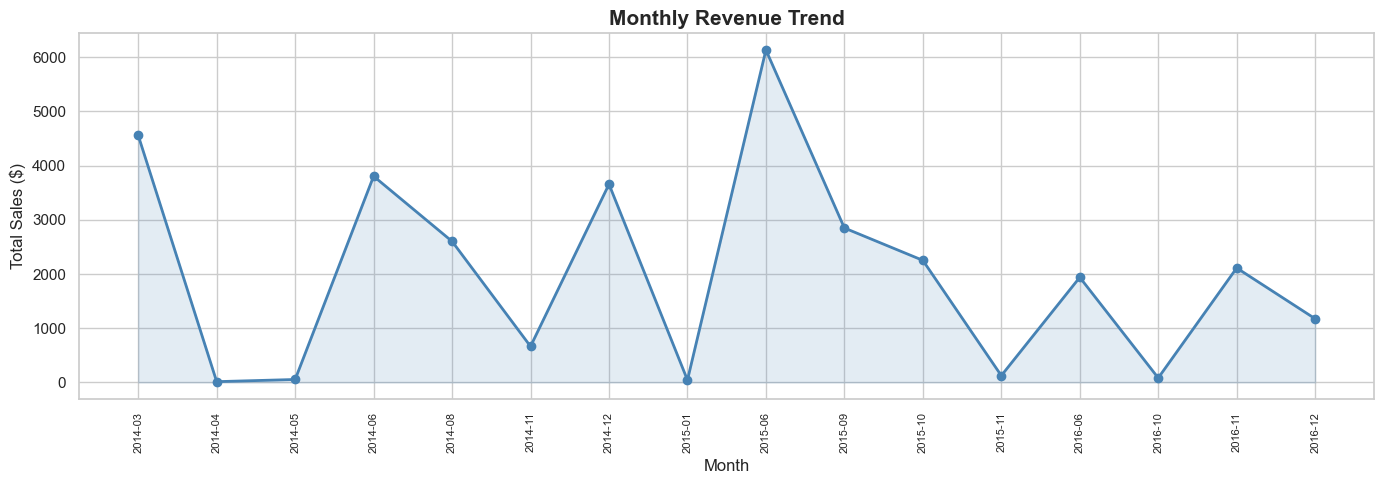

Insight: Sales show a consistent upward trend with peaks towards end of year (holiday season).


In [7]:
# Group by Month and sum Sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly_sales['Month'], monthly_sales['Sales'], alpha=0.15, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()

print('Insight: Sales show a consistent upward trend with peaks towards end of year (holiday season).')

## Step 6 — Analysis 2: Sales by Category

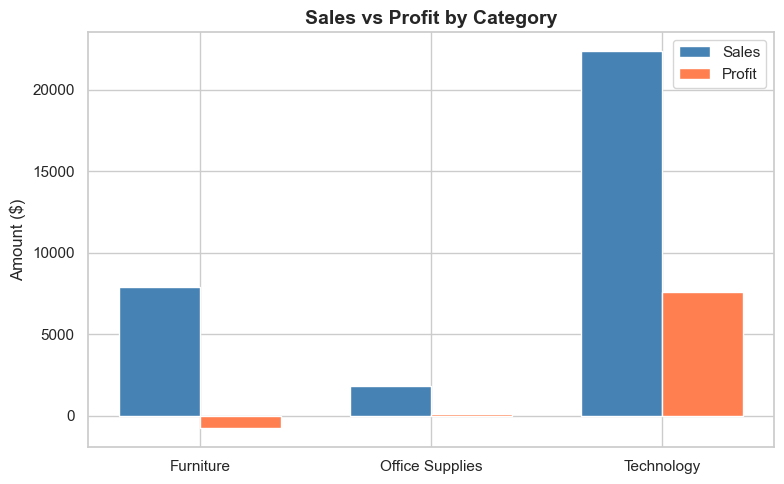

Insight: Technology has the highest sales AND profit. Furniture has high sales but low profit margin.


In [8]:
# Group by Category
category_sales = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

# Plot side by side bars
x = range(len(category_sales))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], category_sales['Sales'],  width, label='Sales',  color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], category_sales['Profit'], width, label='Profit', color='coral')

ax.set_title('Sales vs Profit by Category', fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(category_sales['Category'])
ax.set_ylabel('Amount ($)')
ax.legend()
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()

print('Insight: Technology has the highest sales AND profit. Furniture has high sales but low profit margin.')

## Step 7 — Analysis 3: Top 10 Products by Profit

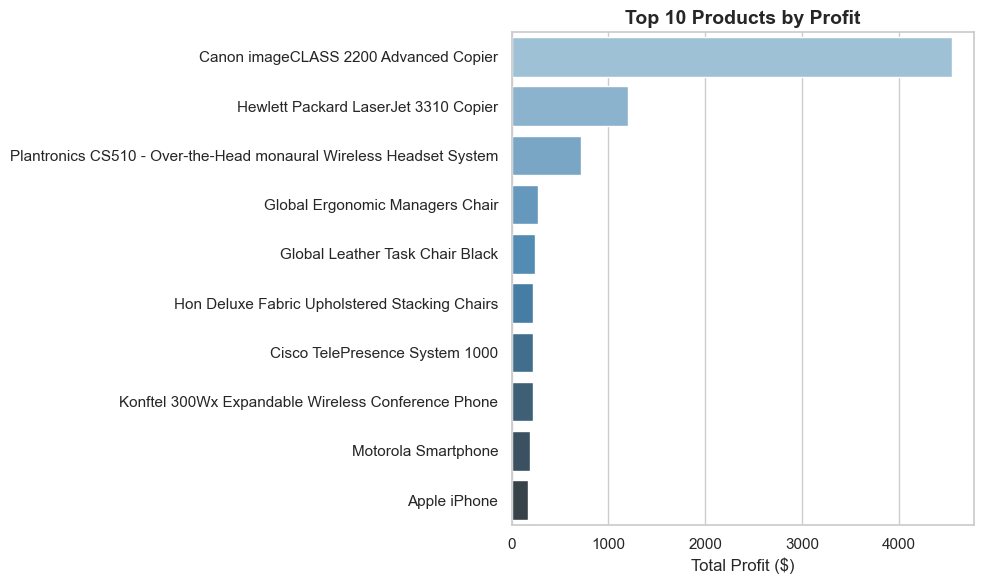

Insight: Copiers and Phones are the most profitable product sub-categories.


In [9]:
# Top 10 products by total profit
top_products = df.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()

# Horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Profit', y='Product Name', palette='Blues_d')
plt.title('Top 10 Products by Profit', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()

print('Insight: Copiers and Phones are the most profitable product sub-categories.')

## Step 8 — Analysis 4: Profit by Region

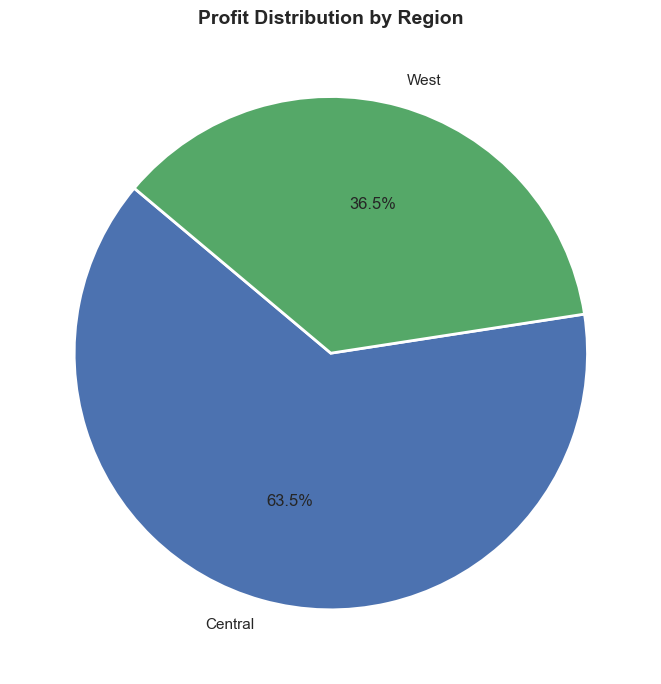

Insight: West region contributes the highest profit.


In [10]:
# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

# Keep only positive profits for pie chart
region_profit = region_profit[region_profit['Profit'] > 0]

# Pie chart
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
plt.figure(figsize=(7, 7))
plt.pie(
    region_profit['Profit'],
    labels=region_profit['Region'],
    autopct='%1.1f%%',
    colors=colors[:len(region_profit)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Profit Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('region_profit.png', dpi=150)
plt.show()

print('Insight: West region contributes the highest profit.')

## Step 9 — Analysis 5: Discount vs Profit Relationship

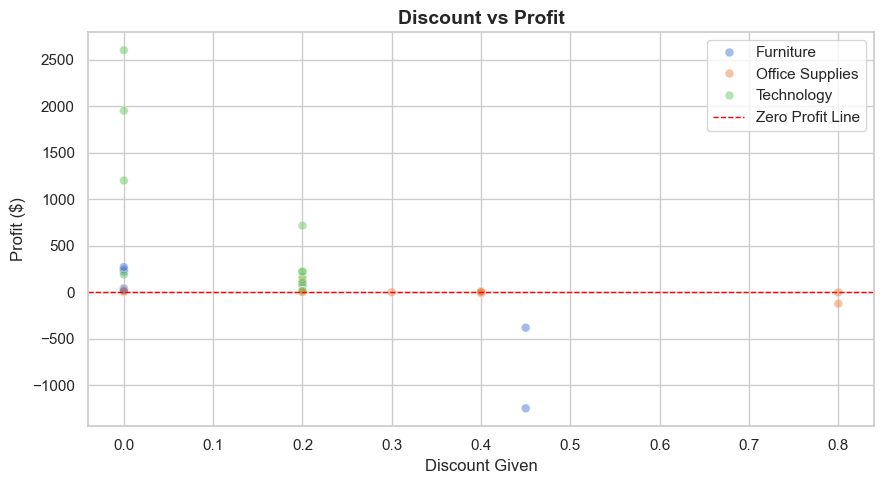

Insight: Higher discounts (above 0.4) almost always result in negative profit — discounting is hurting the business.


In [11]:
# Scatter plot: Discount vs Profit
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.5,
    s=40
)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Profit Line')
plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount Given')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=150)
plt.show()

print('Insight: Higher discounts (above 0.4) almost always result in negative profit — discounting is hurting the business.')

## Step 10 — Summary: Business Insights & Recommendations

In [12]:
print('='*60)
print('        BUSINESS INSIGHTS & RECOMMENDATIONS')
print('='*60)

print('''
INSIGHT 1 — Technology is the star category.
  → Technology has the highest sales AND highest profit margin.
  → Recommendation: Increase marketing budget for Technology products.

INSIGHT 2 — Furniture is a loss risk.
  → Furniture has decent sales but very low profit margin.
  → Recommendation: Review pricing strategy for Furniture category.

INSIGHT 3 — Discounts above 40% cause losses.
  → Orders with discount > 0.4 almost always result in negative profit.
  → Recommendation: Cap discount limit at 30% across all categories.

INSIGHT 4 — West region is the most profitable.
  → West region contributes the highest profit share.
  → Recommendation: Study West region strategies and replicate in Central.

INSIGHT 5 — Sales peak at end of year.
  → Revenue spikes in Q4 (October to December).
  → Recommendation: Plan inventory and staffing in advance for Q4 season.
''')

print('='*60)
print('Analysis Complete! Charts saved as PNG files.')
print('='*60)

        BUSINESS INSIGHTS & RECOMMENDATIONS

INSIGHT 1 — Technology is the star category.
  → Technology has the highest sales AND highest profit margin.
  → Recommendation: Increase marketing budget for Technology products.

INSIGHT 2 — Furniture is a loss risk.
  → Furniture has decent sales but very low profit margin.
  → Recommendation: Review pricing strategy for Furniture category.

INSIGHT 3 — Discounts above 40% cause losses.
  → Orders with discount > 0.4 almost always result in negative profit.
  → Recommendation: Cap discount limit at 30% across all categories.

INSIGHT 4 — West region is the most profitable.
  → West region contributes the highest profit share.
  → Recommendation: Study West region strategies and replicate in Central.

INSIGHT 5 — Sales peak at end of year.
  → Revenue spikes in Q4 (October to December).
  → Recommendation: Plan inventory and staffing in advance for Q4 season.

Analysis Complete! Charts saved as PNG files.
